In [1]:
%reload_ext autoreload
%autoreload 2

In [6]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM


In [7]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))
    x = jnp.where(u < 0.5, eps[0]-3., eps[1]+3)
    return x[None]

[3.158]


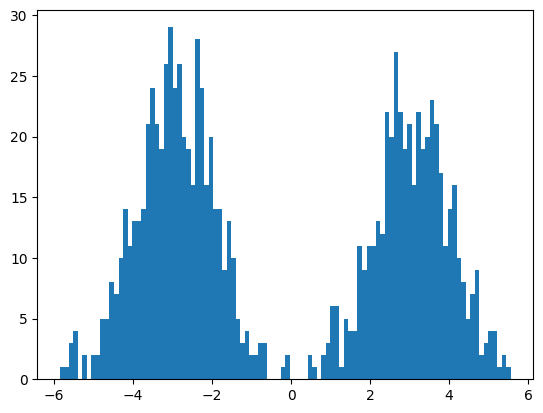

In [8]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [9]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,4, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([d+4,50,50,50,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(1, nnx.Rngs(0))
model = EDM(net, std0=1.)
params = nnx.state(model, nnx.Param)

In [10]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(1e-3))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [11]:
key = jax.random.key(0)

In [12]:
losses = []
for i in range(200):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/10)

In [13]:
nnx.update(model, params)

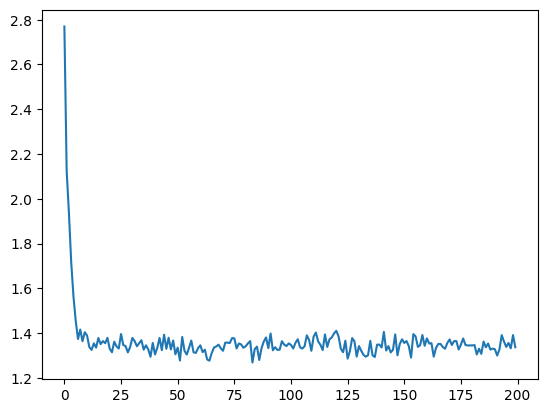

In [14]:
plt.plot(losses)

In [15]:
from probjax.utils.odeint import odeint


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule()

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")


In [16]:
model.marginal_std(model.max_noise)

Array([80.006], dtype=float32)

(array([244., 212., 129., 108.,  58.,  63.,  22.,  20.,  26.,  15.,  19.,
          8.,   7.,   9.,   8.,   2.,   6.,  10.,   3.,   2.,   1.,   1.,
          4.,   2.,   1.,   1.,   0.,   1.,   0.,   0.,   1.,   1.,   0.,
          2.,   0.,   1.,   0.,   3.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   3.,
          1.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([ 0.007,  0.268,  0.53 ,  0.791,  1.053,  1.315,  1.576,  1.838,
         2.099,  2.361,  2.623,  2.884,  3.146,  3.407,  3.669,  3.931,
         4.192,  4.454,  4.715,  4.977,  5.239,  5.5  ,  5.762,  6.023,
         6.285,  6.547,  6.808,  7.07 ,  7.331,  7.593,  7.854,  8.116,
         8.378,  8.639,  8.901

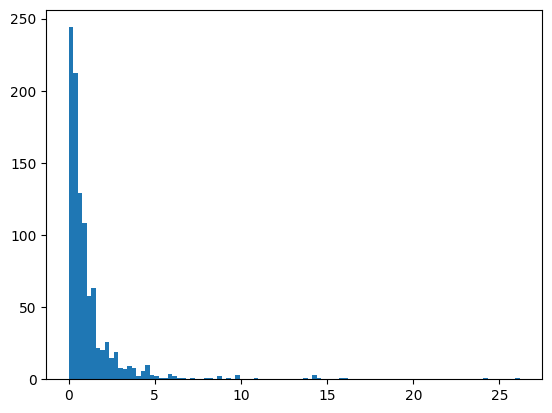

In [17]:
model.lognoise_mean = -0.5
plt.hist(model.noise_schedule(jax.random.key(0), (1000,)).flatten(), bins=100)

In [18]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

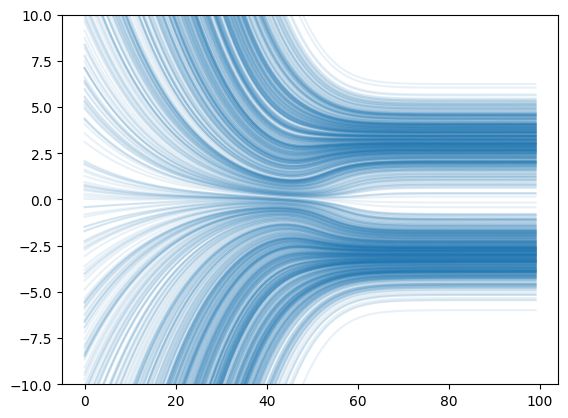

In [19]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

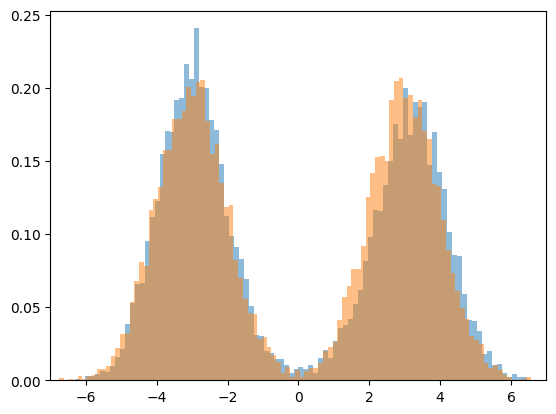

In [20]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [27]:
from probjax.utils.sdeint import sdeint


def sample(rng):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward

    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g

    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")





In [28]:
keys = jax.random.split(key, (10_000,))

In [29]:
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

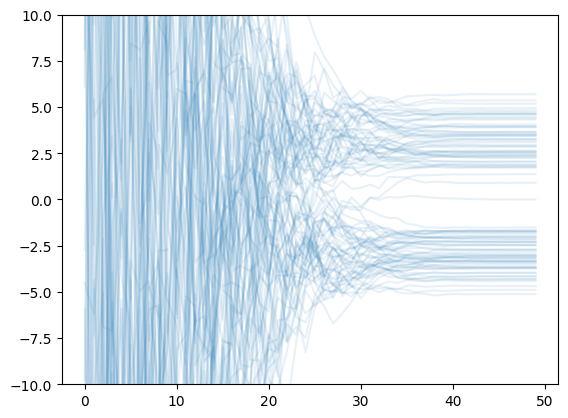

In [30]:
_ = plt.plot(xs[::100,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

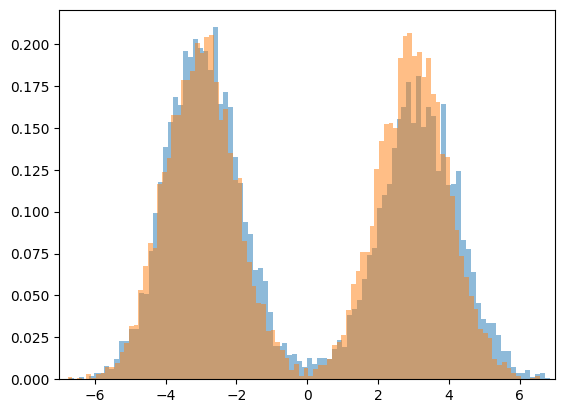

In [31]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)